In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [2]:
du_lieu = pd.read_csv("ratings_baseline_label_encoded.csv")

print(du_lieu.head())
print(du_lieu.shape)


   user_id  movie_id  rating  timestamp  user_enc  movie_enc  user_bias  \
0      196       242       3  881250949         0          0  -0.033937   
1      186       302       3  891717742         1          1  -0.046341   
2       22       377       1  878887116         2          2  -0.124008   
3      244        51       2  880606923         3          3   0.122386   
4      166       346       1  886397596         4          4   0.146212   

   movie_bias  global_mean  baseline_pred  
0    0.544340     3.531887       4.042291  
1    0.725679     3.531887       4.211226  
2   -0.502237     3.531887       2.905642  
3    0.069842     3.531887       3.724115  
4    0.184331     3.531887       3.862431  
(100000, 10)


In [3]:
dac_trung_X = du_lieu[['user_enc', 'movie_enc']]
nhan_y = du_lieu['rating']


In [4]:
X_huan_luyen, X_kiem_tra, y_huan_luyen, y_kiem_tra = train_test_split(
    dac_trung_X,
    nhan_y,
    test_size=0.2,
    random_state=42
)

print("Kích thước tập huấn luyện:", X_huan_luyen.shape)
print("Kích thước tập kiểm tra  :", X_kiem_tra.shape)


Kích thước tập huấn luyện: (80000, 2)
Kích thước tập kiểm tra  : (20000, 2)


In [5]:
knn_regressor = KNeighborsRegressor(
    n_neighbors=20,
    metric='euclidean'
)

knn_regressor.fit(X_huan_luyen, y_huan_luyen)
du_doan_knn = knn_regressor.predict(X_kiem_tra)

rmse_knn = np.sqrt(mean_squared_error(y_kiem_tra, du_doan_knn))
mae_knn  = mean_absolute_error(y_kiem_tra, du_doan_knn)

print("KNN REGRESSOR")
print("RMSE:", rmse_knn)
print("MAE :", mae_knn)


KNN REGRESSOR
RMSE: 1.1120332166801492
MAE : 0.9005525


In [6]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_huan_luyen, y_huan_luyen)
du_doan_random_forest = random_forest.predict(X_kiem_tra)

rmse_rf = np.sqrt(mean_squared_error(y_kiem_tra, du_doan_random_forest))
mae_rf  = mean_absolute_error(y_kiem_tra, du_doan_random_forest)

print("RANDOM FOREST REGRESSOR")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)


RANDOM FOREST REGRESSOR
RMSE: 1.0663375893074085
MAE : 0.8775581316849371


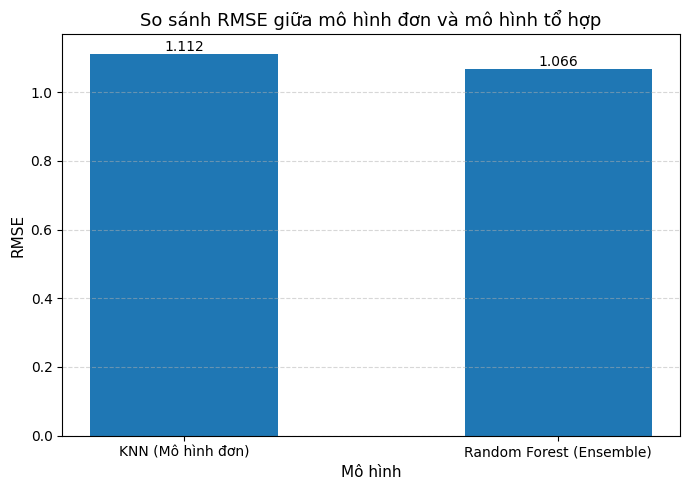

In [7]:
ten_mo_hinh = ['KNN (Mô hình đơn)', 'Random Forest (Ensemble)']
gia_tri_rmse = [rmse_knn, rmse_rf]

plt.figure(figsize=(7,5))

cot = plt.bar(
    ten_mo_hinh,
    gia_tri_rmse,
    width=0.5
)

plt.ylabel("RMSE", fontsize=11)
plt.xlabel("Mô hình", fontsize=11)
plt.title("So sánh RMSE giữa mô hình đơn và mô hình tổ hợp", fontsize=13)

for thanh in cot:
    chieu_cao = thanh.get_height()
    plt.text(
        thanh.get_x() + thanh.get_width()/2,
        chieu_cao,
        f"{chieu_cao:.3f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [8]:
bang_ket_qua = pd.DataFrame({
    "Model": ["KNN Regressor", "Random Forest Regressor"],
    "RMSE": [rmse_knn, rmse_rf],
    "MAE":  [mae_knn, mae_rf]
})

bang_ket_qua.to_csv("knn_rf_sklearn_result.csv", index=False)
print("Đã lưu file knn_rf_sklearn_result.csv")


Đã lưu file knn_rf_sklearn_result.csv
